In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
import plotly.express as py

In [2]:
df=pd.read_csv("Teen_Mental_Health_Dataset.csv")
df=pd.get_dummies(data=df,columns=["gender","platform_usage","social_interaction_level"])
df=df.dropna()

x=df.drop("depression_label",axis=1)
y=df["depression_label"]

ts=[0.05,0.10,0.15,0.2,0.25]
result={"model":[],"test_size":[],"accuracy":[]}
best_accuracy=0
best_model=''

for t in ts:
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=t,random_state=42)

    # KNN
    model=KNeighborsClassifier(n_neighbors=29)
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    acc=accuracy_score(y_pred,y_test)
    result["model"].append("KNN")
    result["test_size"].append(t)
    result["accuracy"].append(acc)
    if acc>best_accuracy:
        best_accuracy=acc
        best_model=model

    # Decision Tree Classifier
    model=DecisionTreeClassifier(criterion="entropy",random_state=42,max_depth=4)
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    acc=accuracy_score(y_pred,y_test)
    result["model"].append("DTC")
    result["test_size"].append(t)
    result["accuracy"].append(acc)
    if acc>best_accuracy:
        best_accuracy=acc
        best_model=model

    # RandomForestClassifier
    model=RandomForestClassifier(criterion="entropy",random_state=42,n_estimators=100,max_depth=4)
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    acc=accuracy_score(y_pred,y_test)
    result["model"].append("RFC")
    result["test_size"].append(t)
    result["accuracy"].append(acc)
    if acc>best_accuracy:
        best_accuracy=acc
        best_model=model

    # SupportVectorMachine
    model=SVC(C=10,kernel='rbf',random_state=42)
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    acc=accuracy_score(y_pred,y_test)
    result["model"].append("SVC")
    result["test_size"].append(t)
    result["accuracy"].append(acc)
    if acc>best_accuracy:
        best_accuracy=acc
        best_model=model


print("Best model is ",best_model,"with accuracy",best_accuracy)

# Graph
dff=pd.DataFrame(result)
py.line(dff,x="test_size",y="accuracy",color="model")

Best model is  DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42) with accuracy 1.0


In [3]:
py.bar(data_frame=result,x="model",y="accuracy")

In [25]:
df=pd.read_csv("created_house_price_prediction.csv")
df=pd.get_dummies(df,columns=["Location"])
df=df.dropna()

x=df.drop("Price",axis=1)
y=df["Price"]

x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

degree=[1,2,3,4,5]
result_d={"degree":[],"r2_score":[],"mse":[]}
best_degree=0
best_score=0

for d in degree:
    poly=PolynomialFeatures(degree=d)
    x_train_poly=poly.fit_transform(x_train)
    x_test_poly=poly.transform(x_test)

    model=LinearRegression()

    model.fit(x_train_poly,y_train)
    y_pred=model.predict(x_test_poly)

    print("For degree",d,":")
    r2=r2_score(y_test,y_pred)
    print("R2 score:",r2)
    mse=mean_squared_error(y_test,y_pred)
    print("Mean Squared Error:",mse)
    print()

    result_d["r2_score"].append(r2)
    result_d["mse"].append(mse)
    result_d["degree"].append(d)
    

    if r2>best_score:
        best_score=r2
        best_degree=d

For degree 1 :
R2 score: 0.21425046975387385
Mean Squared Error: 401114139847949.25

For degree 2 :
R2 score: 0.4962427104963206
Mean Squared Error: 257161046991792.25

For degree 3 :
R2 score: 0.753617061976081
Mean Squared Error: 125775042115161.45

For degree 4 :
R2 score: 0.9075088096931633
Mean Squared Error: 47215458381271.76

For degree 5 :
R2 score: 0.9228918118272955
Mean Squared Error: 39362651052988.875



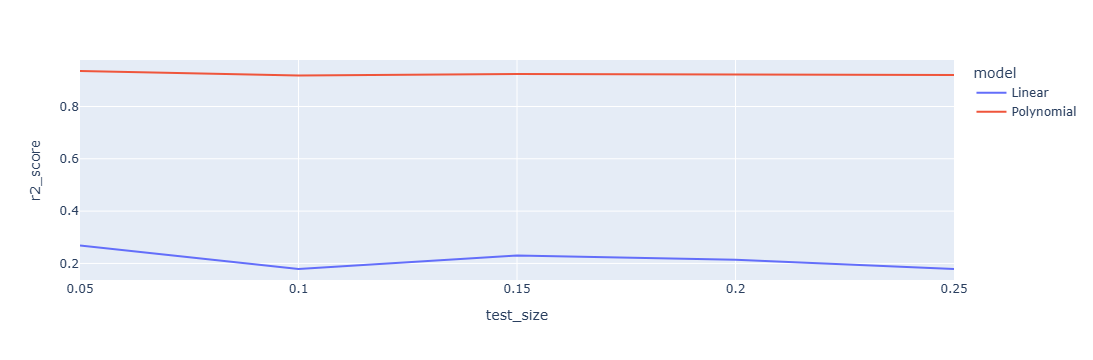

In [26]:
# Model Comparision
ts=[0.05,0.1,0.15,0.2,0.25]
result={"model":[],"r2_score":[],"mse":[],"test_size":[]}
best_score=0
best_model=""

for t in ts:
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=t,random_state=42)

    # LinearRegression
    model=LinearRegression()
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)

    r2=r2_score(y_test,y_pred)
    mse=mean_squared_error(y_test,y_pred)

    if r2>best_score:
        best_score=r2
        best_model=model

    result["r2_score"].append(r2)
    result["mse"].append(mse)
    result["test_size"].append(t)
    result["model"].append("Linear")


    # PolynomialRegression
    poly=PolynomialFeatures(degree=best_degree)
    x_train_poly=poly.fit_transform(x_train)
    x_test_poly=poly.transform(x_test)
    model=LinearRegression()
    model.fit(x_train_poly,y_train)
    y_pred=model.predict(x_test_poly)

    r2=r2_score(y_test,y_pred)
    mse=mean_squared_error(y_test,y_pred)

    if r2>best_score:
        best_score=r2
        best_model=model

    result["r2_score"].append(r2)
    result["mse"].append(mse)
    result["test_size"].append(t)
    result["model"].append("Polynomial")


dff=pd.DataFrame(result)
py.line(dff,x="test_size",y="r2_score",color="model")


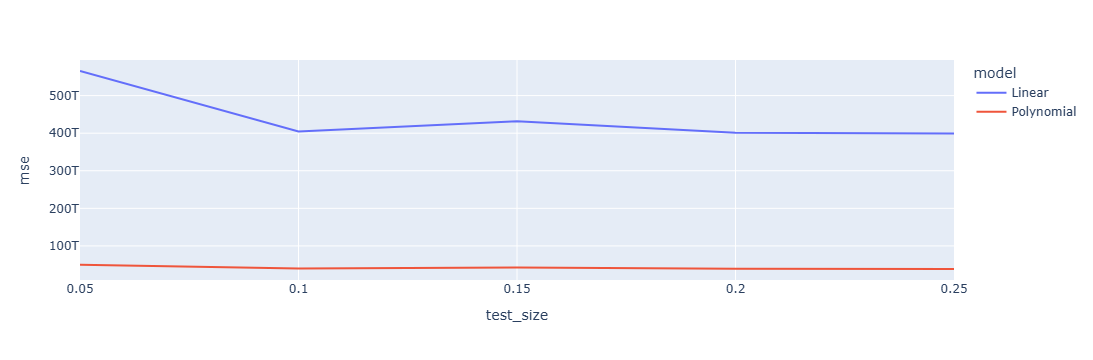

In [27]:
py.line(dff,x="test_size",y="mse",color="model")

In [28]:
# Tables
print("Best Degree=",best_degree)

print("Table 1:")
result_d=pd.DataFrame(result_d)
result_d

Best Degree= 5
Table 1:


,degree,r2_score,mse
0,1,0.214250,4.011141e+14
1,2,0.496243,2.571610e+14
2,3,0.753617,1.257750e+14
3,4,0.907509,4.721546e+13
4,5,0.922892,3.936265e+13


In [29]:
print("Table 2:")
dff

Table 2:


,model,r2_score,mse,test_size
0,Linear,0.268646,5.655044e+14,0.05
1,Polynomial,0.935609,4.978899e+13,0.05
2,Linear,0.178949,4.047876e+14,0.10
3,Polynomial,0.918805,4.003019e+13,0.10
4,Linear,0.230288,4.316472e+14,0.15
5,Polynomial,0.924259,4.247483e+13,0.15
6,Linear,0.214250,4.011141e+14,0.20
7,Polynomial,0.922892,3.936265e+13,0.20
8,Linear,0.178664,3.994572e+14,0.25
9,Polynomial,0.920735,3.855058e+13,0.25


In [30]:
print("Best model=",best_model)

Best model= LinearRegression()
